# 01 Data Setup

This notebook downloads market data, computes SPY log returns, constructs realized volatility, and creates the supervised learning dataset used in the modeling notebook.

Pipeline for this notebook:

1. Download SPY and VIX price data  
2. Compute log returns  
3. Construct 21-day annualized realized volatility  
4. Create lagged volatility features and next-day volatility target  
5. Save processed datasets for later notebooks


## 1. Import packages and project utilities

This notebook uses reusable utility modules from the src/ directory to improve reproducibility and project organization.


In [1]:
# Import useful libraries
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
# Allow notebooks to import modules from ../src
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_utils import download_prices, compute_log_returns
from src.features import compute_realized_volatility, create_vol_features

## 2. Define project paths

Processed datasets are saved to the data/ directory for downstream modeling and risk-analysis workflows.


In [3]:
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"

DATA_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

## 3. Download market data

We use SPY as the primary equity market proxy and VIX as a forward-looking market volatility indicator. Historical market data is downloaded from Yahoo Finance using adjusted closing prices.

In [4]:
tickers = ["SPY", "^VIX"]
start_date = "2015-01-01"
end_date = "2025-01-01"

prices = download_prices(tickers, start=start_date, end=end_date)
prices.head()

[*********************100%***********************]  2 of 2 completed


Ticker,SPY,^VIX
Date,,
2015-01-02,170.125000,17.790001
2015-01-05,167.052612,19.920000
2015-01-06,165.479111,21.120001
2015-01-07,167.541199,19.309999
2015-01-08,170.514221,17.010000


In [5]:
prices.tail()

Ticker,SPY,^VIX
Date,,
2024-12-24,592.702148,14.27
2024-12-26,592.741638,14.73
2024-12-27,586.502014,15.95
2024-12-30,579.809021,17.40
2024-12-31,577.699707,17.35


## 4. Compute log returns

Log returns are used because they are standard in financial time-series analysis and are additive over time.


In [6]:
returns = compute_log_returns(prices)
returns.head()

Ticker,SPY,^VIX
Date,,
2015-01-05,-0.018225,0.113088
2015-01-06,-0.009464,0.058496
2015-01-07,0.012384,-0.089597
2015-01-08,0.017589,-0.126822
2015-01-09,-0.008046,0.031252


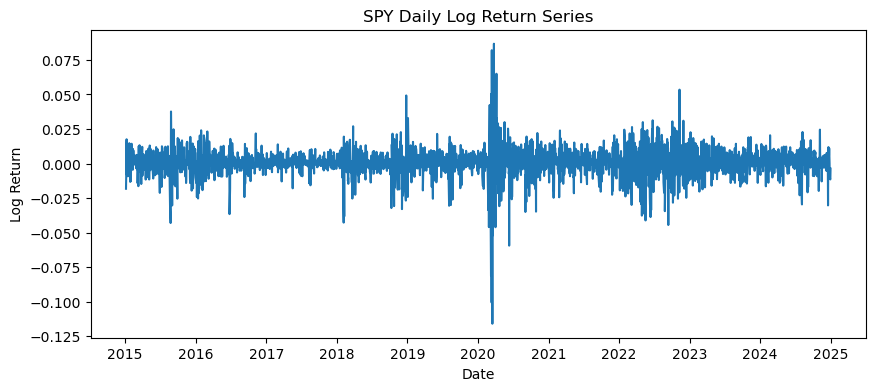

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(returns.index, returns["SPY"])
plt.title("SPY Daily Log Return Series")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.show()

The return series exhibits volatility clustering, particularly during periods of market stress such as 2020.

## 5. Save prices and returns

Save results for later use.


In [8]:
prices.to_csv(DATA_DIR / "prices.csv")
returns.to_csv(DATA_DIR / "returns.csv")

## 6. Construct realized volatility

Realized volatility is computed as the rolling standard deviation of SPY daily log returns. A 21-day rolling window is used to approximate one trading month. The volatility is annualized using $\sqrt{252}$, assuming 252 trading days per year..


In [9]:
spy_returns = returns["SPY"]

realized_vol_annualized = compute_realized_volatility(
    spy_returns,
    window=21,
    annualize=True
)

realized_vol_annualized.head()

Date
2015-02-03    0.178846
2015-02-04    0.167061
2015-02-05    0.165993
2015-02-06    0.161693
2015-02-09    0.150427
Name: SPY, dtype: float64

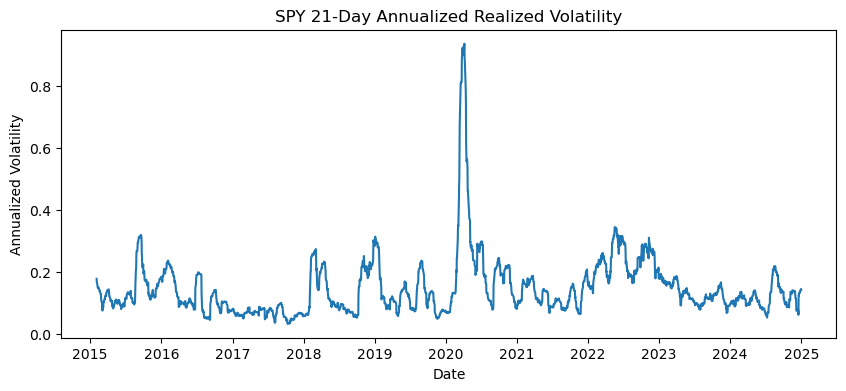

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(realized_vol_annualized.index, realized_vol_annualized)
plt.title("SPY 21-Day Annualized Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.show()

In [11]:
realized_vol_annualized.to_csv(DATA_DIR / "realized_volatility.csv")

## 7. Create supervised learning dataset

The supervised learning target is next-day realized volatility. Lagged volatility features are included to capture volatility persistence over time.


In [12]:
model_data = create_vol_features(realized_vol_annualized)
model_data.head()

,vol,vol_lag1,vol_lag5,vol_lag10,vol_lag21,target
Date,,,,,,
2015-03-05,0.076596,0.088954,0.117697,0.138447,0.178846,0.092105
2015-03-06,0.092105,0.076596,0.106632,0.138762,0.167061,0.086748
2015-03-09,0.086748,0.092105,0.104768,0.130694,0.165993,0.104233
2015-03-10,0.104233,0.086748,0.092912,0.128510,0.161693,0.103366
2015-03-11,0.103366,0.104233,0.088954,0.128742,0.150427,0.106206


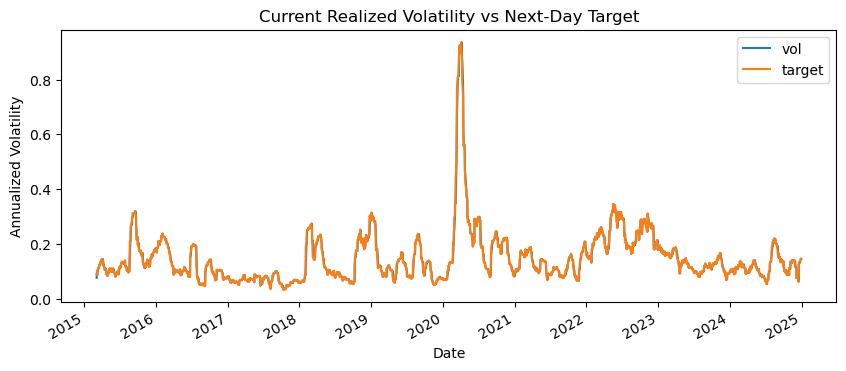

In [13]:
model_data[["vol", "target"]].plot(figsize=(10, 4))
plt.title("Current Realized Volatility vs Next-Day Target")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.show()

In [14]:
model_data.to_csv(DATA_DIR / "model_data.csv")

## 8. Summary

This notebook creates four processed datasets:

- `prices.csv`: adjusted daily prices for SPY and VIX  
- `returns.csv`: daily log returns  
- `realized_volatility.csv`: 21-day annualized realized volatility for SPY  
- `model_data.csv`: lagged volatility features and next-day volatility target

These files will be used in the modeling and VaR application notebooks.
